# Import Libraries

In [1]:
# Importing necessary libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS   # fixed typo: worldcloud -> wordcloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import re
from textblob import TextBlob
import nltk

# Download NLTK data (only needs to run once; can be commented out after first run)
nltk.download('punkt')

# Set visualization style
sns.set_style('whitegrid')

[nltk_data] Downloading package punkt to /Users/brianrono/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# Load Dataset

In [2]:
# Load the Airbnb reviews dataset
file_path = "airbnb_reviews_checkpoint.csv"
df = pd.read_csv(file_path)

print("Initial Shape:", df.shape)
df.head(3)


Initial Shape: (12302, 11)


,review_id,reviewer_name,reviewer_location,rating,review_date,stay_duration,review_text,source_property_id,source_property_url,source_location,listing_index
0,1507929580880824667,Norah,2 years on Airbnb,NaN,",\n·",Stayed a few nights,This space warmed my heart! The stunning view ...,1036777293444526725,https://www.airbnb.com/rooms/10367772934445267...,Mombasa\n_\n_\nGuest favorite\nGuest favorite\...,0
1,1506447949293551185,Victor,4 years on Airbnb,NaN,",\n·",Stayed a few nights,My experience at this residence was exemplary....,1036777293444526725,https://www.airbnb.com/rooms/10367772934445267...,Mombasa\n_\n_\nGuest favorite\nGuest favorite\...,0
2,1473145684168684623,Sylvia,"Nairobi, Kenya",NaN,",\n·",Stayed a few nights,Such a beautiful and airy place. Scenic views ...,1036777293444526725,https://www.airbnb.com/rooms/10367772934445267...,Mombasa\n_\n_\nGuest favorite\nGuest favorite\...,0


# Data Cleaning 

In [3]:
# Drop rows where review_text is missing
df = df.dropna(subset=["review_text"])

# Drop 'rating' column (all nulls)
if "rating" in df.columns:
    df = df.drop(columns=["rating"])

# Clean review_date (remove junk + parse datetime if possible)
df["review_date"] = (
    df["review_date"]
    .astype(str)
    .str.replace(r"[^0-9A-Za-z\s-]", "", regex=True)
    .str.strip()
)
df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")

# Clean source_location (take only first part, drop extra)
df["source_location"] = df["source_location"].astype(str).str.split("\n").str[0].str.strip()

print("After Cleaning:", df.shape)
print("\nMissing values per column:\n", df.isnull().sum())

After Cleaning: (12299, 10)

Missing values per column:
 review_id                  0
reviewer_name              0
reviewer_location          0
review_date            12299
stay_duration              0
review_text                0
source_property_id         0
source_property_url        0
source_location            0
listing_index              0
dtype: int64


# EDA - Reviews by County/City

/var/folders/hk/9q5rgqm970gcnk6z0xvy1p7m0000gn/T/ipykernel_56992/1295006953.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reviews_per_location.values, y=reviews_per_location.index, palette="viridis")


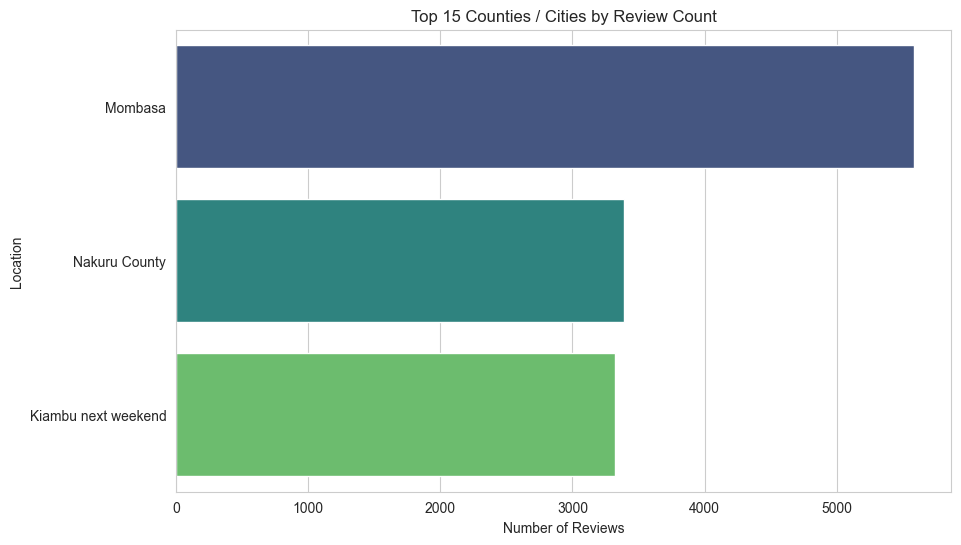

In [4]:
# Count reviews per location
reviews_per_location = df["source_location"].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=reviews_per_location.values, y=reviews_per_location.index, palette="viridis")
plt.title("Top 15 Counties / Cities by Review Count")
plt.xlabel("Number of Reviews")
plt.ylabel("Location")
plt.show()